In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [3]:
# image parameters
img_height, img_width = 32, 32

# create image dataset

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    'images/',
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width)
)

Found 15 files belonging to 3 classes.


In [13]:
class_names = train_ds.class_names
print(f"Detected classes: {class_names}")

Detected classes: ['Blue', 'Green', 'Red']


In [14]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# init model

In [15]:
def build_image_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(img_height, img_width, 3)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    return model

# creating model with differnet initializations

In [ ]:
# creating different models (with different random initializations) to form an ensemble
ensemble_size = 5
ensemble = []
print("Training ensemble...")
for i in range(ensemble_size):
    m = build_image_model()
    m.fit(train_ds, epochs=30, verbose=0)
    ensemble.append(m)

Training ensemble...


c:\Users\tamma\AI\AI ROADMAP\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
ensemble

[<Sequential name=sequential, built=True>,
 <Sequential name=sequential_1, built=True>,
 <Sequential name=sequential_2, built=True>,
 <Sequential name=sequential_3, built=True>,
 <Sequential name=sequential_4, built=True>]

# creating code for estimation of simplex coordinates

In [19]:
# get simplex cordinates 

def get_simplex_coords(probs):
    # Corners: Index 0, 1, 2 mapping to class_names
    # Assuming class_names order: [B, G, R]
    b_corner = np.array([0.5, np.sqrt(3)/2]) # Top
    g_corner = np.array([1, 0])              # Right
    r_corner = np.array([0, 0])              # Left
    
    # Coordinates weighted by probability
    pos = probs[0]*b_corner + probs[1]*g_corner + probs[2]*r_corner
    return pos

In [26]:
def predict_and_plot_image(img_path):
    # 1. Load and preprocess
    img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)

    # 2. Get predictions from all models
    # preds shape: (ensemble_size, 3)
    preds = np.array([m.predict(img_array, verbose=0)[0] for m in ensemble])
    mean_pred = np.mean(preds, axis=0)
    
    # 3. Calculate Variance (The "Spread")
    # We calculate the variance of the probabilities across the ensemble
    # High variance = High Epistemic Uncertainty (Models disagree)
    ensemble_variance = np.var(preds, axis=0) 
    total_variance = np.sum(ensemble_variance) # Sum of variances for all 3 classes

    # 4. Display Softmax Outputs and Variance
    print(f"\n--- Analysis for: {os.path.basename(img_path)} ---")
    print(f"{'Model':<10} | {class_names[0]:<8} | {class_names[1]:<8} | {class_names[2]:<8}")
    print("-" * 45)
    for i, p in enumerate(preds):
        print(f"Member {i+1:<3} | {p[0]:.4f}   | {p[1]:.4f}   | {p[2]:.4f}")
    print("-" * 45)
    print(f"AVERAGE    | {mean_pred[0]:.4f}   | {mean_pred[1]:.4f}   | {mean_pred[2]:.4f}")
    print(f"VARIANCE   | Total Spread: {total_variance:.6f}")

    # 5. Plotting on Simplex
    plt.figure(figsize=(7, 6))
    triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])
    plt.plot(triangle[:,0], triangle[:,1], 'k-', alpha=0.3)
    
    plt.text(-0.05, -0.05, class_names[2], color='red', fontsize=12, fontweight='bold')
    plt.text(1.02, -0.05, class_names[1], color='green', fontsize=12, fontweight='bold')
    plt.text(0.48, 0.92, class_names[0], color='blue', fontsize=12, fontweight='bold')

    # Plot ensemble members
    coords = []
    for p in preds:
        coord = get_simplex_coords(p)
        coords.append(coord)
        plt.scatter(coord[0], coord[1], c='gray', alpha=0.5, s=40)

    # Plot Mean Prediction
    mean_coord = get_simplex_coords(mean_pred)
    plt.scatter(mean_coord[0], mean_coord[1], c='gold', marker='*', s=250, edgecolors='black', label='Ensemble Mean')

    plt.title(f"Uncertainty: {os.path.basename(img_path)}\nSpread (Variance): {total_variance:.5f}")
    plt.legend()
    plt.axis('off')
    plt.show()

In [27]:
import matplotlib.image as mpimg

def display_image(img_path):
    """Simple function to display an image from a file path."""
    try:
       
        img = mpimg.imread(img_path)
        
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        
        plt.title(f"Input: {img_path.split('/')[-1]}")
        plt.axis('off') 
        plt.show()
        
    except Exception as e:
        print(f"Error loading image: {e}")


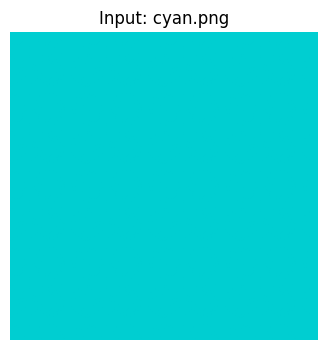


--- Analysis for: cyan.png ---
Model      | Blue     | Green    | Red     
---------------------------------------------
Member 1   | 0.4298   | 0.5702   | 0.0000
Member 2   | 0.6539   | 0.3461   | 0.0000
Member 3   | 0.5296   | 0.4704   | 0.0000
Member 4   | 0.9218   | 0.0022   | 0.0760
Member 5   | 0.9258   | 0.0742   | 0.0000
---------------------------------------------
AVERAGE    | 0.6922   | 0.2926   | 0.0152
VARIANCE   | Total Spread: 0.090445


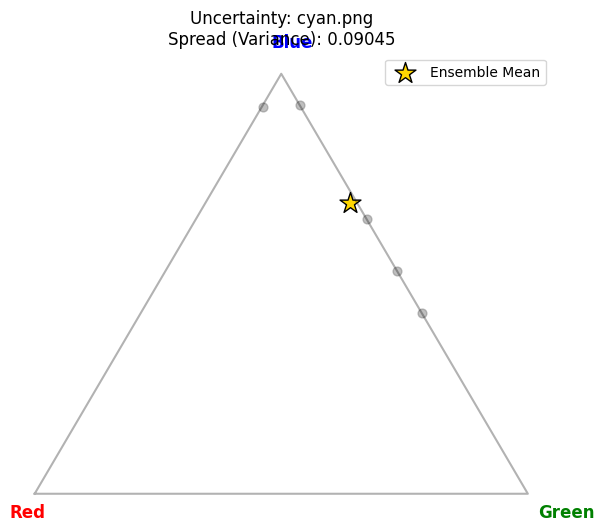

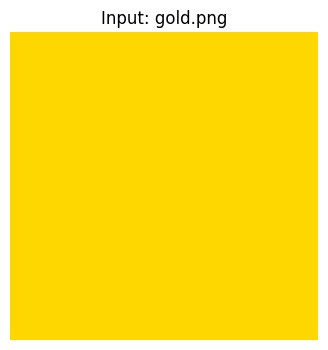


--- Analysis for: gold.png ---
Model      | Blue     | Green    | Red     
---------------------------------------------
Member 1   | 0.0000   | 0.0015   | 0.9985
Member 2   | 0.0000   | 0.4869   | 0.5131
Member 3   | 0.0000   | 0.5503   | 0.4497
Member 4   | 0.0000   | 0.2015   | 0.7985
Member 5   | 0.0000   | 0.0048   | 0.9952
---------------------------------------------
AVERAGE    | 0.0000   | 0.2490   | 0.7510
VARIANCE   | Total Spread: 0.108220


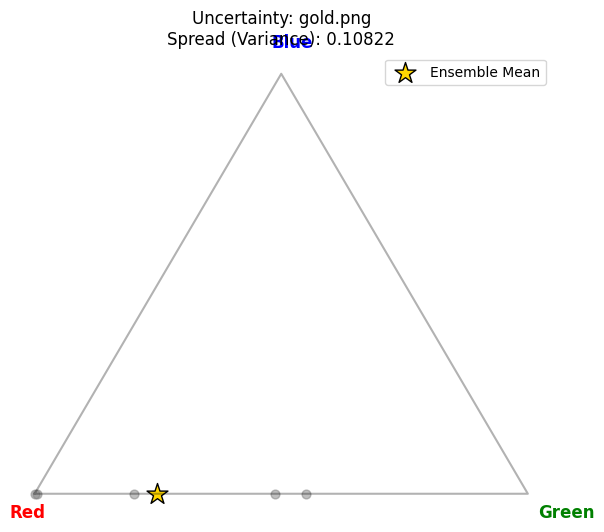

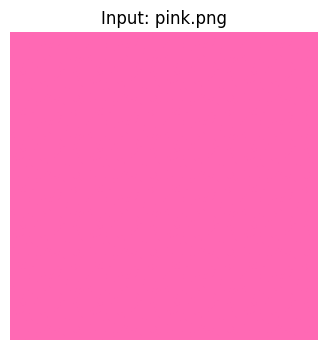


--- Analysis for: pink.png ---
Model      | Blue     | Green    | Red     
---------------------------------------------
Member 1   | 0.0013   | 0.0000   | 0.9987
Member 2   | 0.0037   | 0.0000   | 0.9963
Member 3   | 0.6366   | 0.0000   | 0.3634
Member 4   | 0.0036   | 0.0000   | 0.9964
Member 5   | 0.0002   | 0.0000   | 0.9998
---------------------------------------------
AVERAGE    | 0.1291   | 0.0000   | 0.8709
VARIANCE   | Total Spread: 0.128770


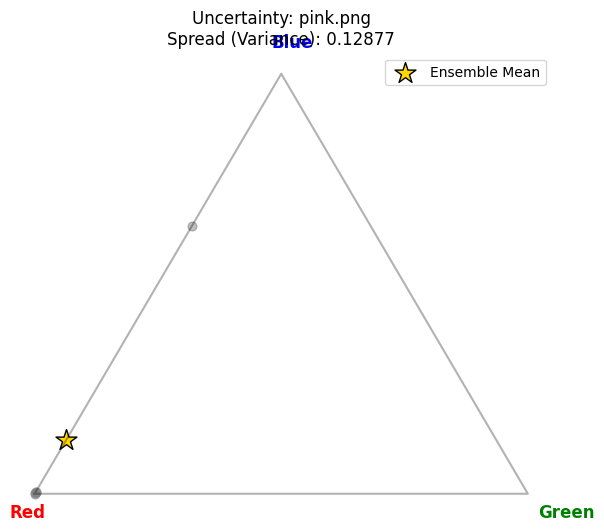

In [29]:
test_images_paths = ['test_images/cyan.png', 'test_images/gold.png', 'test_images/pink.png']
for img_path in test_images_paths:
    display_image(img_path)
    predict_and_plot_image(img_path)